# Modelling Naive Bayes — Klasifikasi Kelayakan Beasiswa
## Referensi: JATI Vol. 7 No. 1, Februari 2023

Tahapan KDD yang dilakukan:
1. ✅ Data Selection
2. ✅ Preprocessing
3. 🔄 **Transformation** ← Dimulai di sini
4. 🔄 **Data Mining (Naive Bayes)**
5. 🔄 **Interpretation / Evaluation**

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

sns.set(style='whitegrid')
print('Library berhasil diimport.')

Library berhasil diimport.


---
## Load Data Hasil Preprocessing

In [2]:
df = pd.read_csv('dataset_kelayakan_beasiswa_clean.csv')
print('Shape data:', df.shape)
df.head()

Shape data: (1815, 22)


,IPK,Semester,Jurusan,Pernah_Mengulang,Pendapatan_Orang_Tua,Pekerjaan_Orang_Tua,Jumlah_Tanggungan,Status_Tempat_Tinggal,Asal_Daerah,Aktif_Organisasi,...,Skor_Motivasi_Tertulis,Surat_Rekomendasi,Pernah_Mendapat_Beasiswa,Skor_Keaktifan_Kampus,Rekam_Ketidakhadiran,Pernah_Melawan_Hukum,Jenis_Kelamin,Skor_Literasi_Finansial,Status_Kelayakan,Jumlah_Beasiswa_Per_Semester
0,3.40,2,teknik informatika,tidak,4608603,pedagang,2,menumpang,3t,tidak,...,77,ada,ya,55,6,tidak,laki-laki,71,layak,3667971
1,3.14,7,kedokteran,tidak,5167265,tidak bekerja,1,milik sendiri,perkotaan,ya,...,98,tidak,ya,55,12,tidak,perempuan,77,tidak layak,0
2,3.83,5,teknik informatika,tidak,9496414,petani,4,milik sendiri,pedesaan,tidak,...,73,ada,ya,52,7,tidak,laki-laki,29,tidak layak,0
3,3.51,2,ekonomi,tidak,6620868,pedagang,3,kontrak,pedesaan,ya,...,88,ada,ya,60,14,tidak,laki-laki,87,layak,4720280
4,3.01,1,kedokteran,tidak,5792423,karyawan swasta,3,milik sendiri,pedesaan,tidak,...,91,tidak,tidak,91,14,tidak,laki-laki,31,tidak layak,0


---
## Tahap 3: TRANSFORMASI

Sesuai jurnal, tahapan transformasi meliputi:
- Atribut `Status_Kelayakan` dijadikan **Label** (target klasifikasi)
- Kolom `Jumlah_Beasiswa_Per_Semester` dihapus (merupakan turunan label, bukan fitur input)
- Semua fitur kategorikal di-encode menggunakan **Label Encoding**

In [3]:
# Hapus kolom yang merupakan derived column (bukan fitur)
df = df.drop(columns=['Jumlah_Beasiswa_Per_Semester'])

# Pisahkan fitur (X) dan label (y)
X = df.drop(columns=['Status_Kelayakan'])
y = df['Status_Kelayakan']   # 'layak' / 'tidak layak'

print('Jumlah fitur:', X.shape[1])
print('Jumlah data :', X.shape[0])
print('\nDaftar Fitur:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

Jumlah fitur: 20
Jumlah data : 1815

Daftar Fitur:
   1. IPK
   2. Semester
   3. Jurusan
   4. Pernah_Mengulang
   5. Pendapatan_Orang_Tua
   6. Pekerjaan_Orang_Tua
   7. Jumlah_Tanggungan
   8. Status_Tempat_Tinggal
   9. Asal_Daerah
  10. Aktif_Organisasi
  11. Jumlah_Kegiatan_Relawan
  12. Pengalaman_Magang
  13. Skor_Motivasi_Tertulis
  14. Surat_Rekomendasi
  15. Pernah_Mendapat_Beasiswa
  16. Skor_Keaktifan_Kampus
  17. Rekam_Ketidakhadiran
  18. Pernah_Melawan_Hukum
  19. Jenis_Kelamin
  20. Skor_Literasi_Finansial


Distribusi Label:
Status_Kelayakan
tidak layak    1458
layak           357
Name: count, dtype: int64

Persentase Layak      : 19.7%
Persentase Tidak Layak: 80.3%


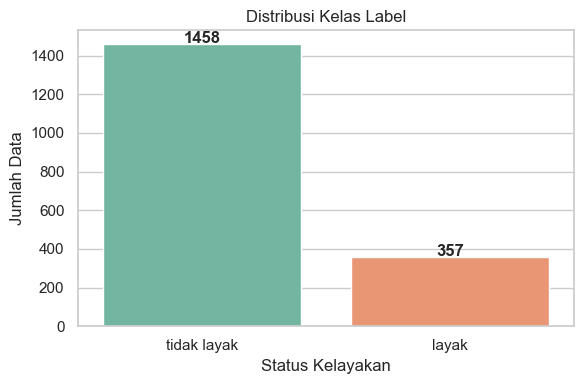

In [5]:
# Cek distribusi label
label_counts = y.value_counts()
print('Distribusi Label:')
print(label_counts)
print(f'\nPersentase Layak      : {label_counts.get("layak", 0)/len(y)*100:.1f}%')
print(f'Persentase Tidak Layak: {label_counts.get("tidak layak", 0)/len(y)*100:.1f}%')

plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette='Set2', legend=False)
plt.title('Distribusi Kelas Label')
plt.ylabel('Jumlah Data')
plt.xlabel('Status Kelayakan')
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Label Encoding untuk kolom kategorikal
le = LabelEncoder()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

X_encoded = X.copy()
for col in categorical_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Encode label: 'layak' -> 1, 'tidak layak' -> 0
y_encoded = (y == 'layak').astype(int)

print('Kolom yang di-encode:')
for c in categorical_cols:
    print(f'  - {c}')
print('\nLabel encoding: layak=1, tidak layak=0')
print('\nContoh data setelah transformasi:')
X_encoded.head()

Kolom yang di-encode:
  - Jurusan
  - Pernah_Mengulang
  - Pekerjaan_Orang_Tua
  - Status_Tempat_Tinggal
  - Asal_Daerah
  - Aktif_Organisasi
  - Pengalaman_Magang
  - Surat_Rekomendasi
  - Pernah_Mendapat_Beasiswa
  - Pernah_Melawan_Hukum
  - Jenis_Kelamin

Label encoding: layak=1, tidak layak=0

Contoh data setelah transformasi:


,IPK,Semester,Jurusan,Pernah_Mengulang,Pendapatan_Orang_Tua,Pekerjaan_Orang_Tua,Jumlah_Tanggungan,Status_Tempat_Tinggal,Asal_Daerah,Aktif_Organisasi,Jumlah_Kegiatan_Relawan,Pengalaman_Magang,Skor_Motivasi_Tertulis,Surat_Rekomendasi,Pernah_Mendapat_Beasiswa,Skor_Keaktifan_Kampus,Rekam_Ketidakhadiran,Pernah_Melawan_Hukum,Jenis_Kelamin,Skor_Literasi_Finansial
0,3.40,2,7,0,4608603,2,2,1,0,0,4,1,77,0,1,55,6,0,0,71
1,3.14,7,2,0,5167265,5,1,2,2,1,1,1,98,1,1,55,12,0,1,77
2,3.83,5,7,0,9496414,4,4,2,1,0,4,0,73,0,1,52,7,0,0,29
3,3.51,2,0,0,6620868,2,3,0,1,1,5,0,88,0,1,60,14,0,0,87
4,3.01,1,2,0,5792423,1,3,2,1,0,5,1,91,1,0,91,14,0,0,31


---
## Tahap 4: DATA MINING — Naive Bayes

Sesuai jurnal:
- Data dibagi **80% training** dan **20% testing** (Split Data)
- Model **GaussianNB** (Naive Bayes) dilatih
- Model diuji dengan Apply Model

> **Catatan:** Dataset memiliki ketidakseimbangan kelas (~80% Tidak Layak vs ~20% Layak).
> Ditambahkan teknik **Oversampling** pada data training untuk meningkatkan performa model.

In [7]:
# Split Data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Jumlah data training : {len(X_train)}')
print(f'Jumlah data testing  : {len(X_test)}')
print(f'\nDistribusi kelas pada training set:')
print(y_train.value_counts())

Jumlah data training : 1452
Jumlah data testing  : 363

Distribusi kelas pada training set:
Status_Kelayakan
0    1166
1     286
Name: count, dtype: int64


In [8]:
train_df = X_train.copy()
train_df['label'] = y_train.values

majority_class = train_df[train_df['label'] == 0]
minority_class = train_df[train_df['label'] == 1]

minority_upsampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)

train_balanced = pd.concat([majority_class, minority_upsampled])
X_train_bal = train_balanced.drop('label', axis=1)
y_train_bal = train_balanced['label']

print('Distribusi kelas setelah oversampling:')
print(y_train_bal.value_counts())

Distribusi kelas setelah oversampling:
label
0    1166
1    1166
Name: count, dtype: int64


In [9]:
nb_model = GaussianNB()
nb_model.fit(X_train_bal, y_train_bal)

# Prediksi
y_pred       = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]

print('Model Naive Bayes berhasil dilatih.')
print(f'Jumlah data uji: {len(X_test)}')
print(f'Prediksi Layak (1)      : {(y_pred == 1).sum()}')
print(f'Prediksi Tidak Layak (0): {(y_pred == 0).sum()}')

Model Naive Bayes berhasil dilatih.
Jumlah data uji: 363
Prediksi Layak (1)      : 146
Prediksi Tidak Layak (0): 217


---
## Tahap 5: INTERPRETATION / EVALUATION

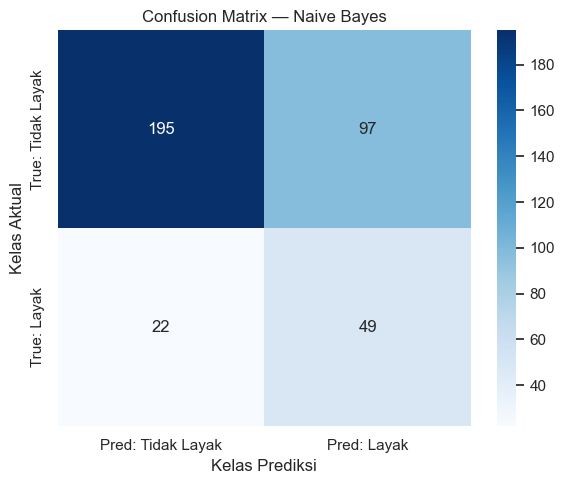

True Positive  (TP): 49  — prediksi Layak dan memang Layak
True Negative  (TN): 195  — prediksi Tidak Layak dan memang Tidak Layak
False Positive (FP): 97   — prediksi Layak padahal Tidak Layak
False Negative (FN): 22   — prediksi Tidak Layak padahal Layak


In [10]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Tidak Layak', 'Pred: Layak'],
    yticklabels=['True: Tidak Layak', 'True: Layak']
)
plt.title('Confusion Matrix — Naive Bayes')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.tight_layout()
plt.show()

print(f'True Positive  (TP): {tp}  — prediksi Layak dan memang Layak')
print(f'True Negative  (TN): {tn}  — prediksi Tidak Layak dan memang Tidak Layak')
print(f'False Positive (FP): {fp}   — prediksi Layak padahal Tidak Layak')
print(f'False Negative (FN): {fn}   — prediksi Tidak Layak padahal Layak')

In [11]:
# === ACCURACY ===
accuracy = accuracy_score(y_test, y_pred)

print('=== 1. AKURASI ===')
print(f'Formula : (TP + TN) / (TP + TN + FP + FN) x 100%')
print(f'        = ({tp} + {tn}) / ({tp} + {tn} + {fp} + {fn}) x 100%')
print(f'        = {accuracy*100:.2f}%')

=== 1. AKURASI ===
Formula : (TP + TN) / (TP + TN + FP + FN) x 100%
        = (49 + 195) / (49 + 195 + 97 + 22) x 100%
        = 67.22%


In [12]:
# === PRECISION ===
precision_ya    = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
precision_tidak = precision_score(y_test, y_pred, pos_label=0, zero_division=0)

print('=== 2. PRECISION ===')
print(f'Formula (class Layak) : TP / (TP + FP) x 100%')
print(f'                      = {tp} / ({tp} + {fp}) x 100% = {precision_ya*100:.2f}%')
print()
print(f'Class Precision YA    (Layak)     : {precision_ya*100:.2f}%')
print(f'Class Precision TIDAK (Tdk Layak) : {precision_tidak*100:.2f}%')

=== 2. PRECISION ===
Formula (class Layak) : TP / (TP + FP) x 100%
                      = 49 / (49 + 97) x 100% = 33.56%

Class Precision YA    (Layak)     : 33.56%
Class Precision TIDAK (Tdk Layak) : 89.86%


In [13]:
# === RECALL ===
recall_ya    = recall_score(y_test, y_pred, pos_label=1)
recall_tidak = recall_score(y_test, y_pred, pos_label=0)

print('=== 3. RECALL ===')
print(f'Formula (class Layak) : TP / (TP + FN) x 100%')
print(f'                      = {tp} / ({tp} + {fn}) x 100% = {recall_ya*100:.2f}%')
print()
print(f'Class Recall YA    (Layak)     : {recall_ya*100:.2f}%')
print(f'Class Recall TIDAK (Tdk Layak) : {recall_tidak*100:.2f}%')

=== 3. RECALL ===
Formula (class Layak) : TP / (TP + FN) x 100%
                      = 49 / (49 + 22) x 100% = 69.01%

Class Recall YA    (Layak)     : 69.01%
Class Recall TIDAK (Tdk Layak) : 66.78%


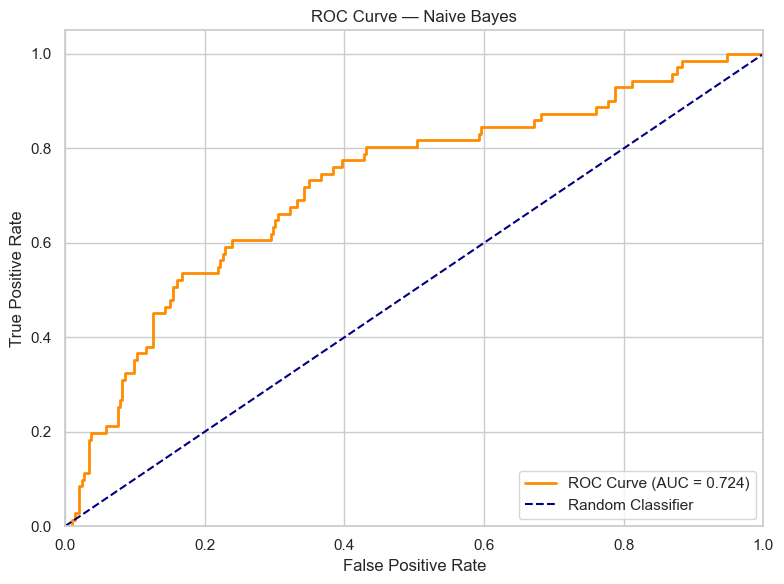

=== 4. AUC ===
AUC Score : 0.724
Kategori  : Fair Classification

Tabel Kategori AUC (sesuai jurnal):
  0.90 – 1.00 = Excellent Classification
  0.80 – 0.90 = Good Classification
  0.70 – 0.80 = Fair Classification
  0.60 – 0.70 = Poor Classification
  0.50 – 0.60 = Failure


In [14]:

auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Naive Bayes')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

if auc_score >= 0.90:
    kategori_auc = 'Excellent Classification'
elif auc_score >= 0.80:
    kategori_auc = 'Good Classification'
elif auc_score >= 0.70:
    kategori_auc = 'Fair Classification'
elif auc_score >= 0.60:
    kategori_auc = 'Poor Classification'
else:
    kategori_auc = 'Failure'

print('=== 4. AUC ===')
print(f'AUC Score : {auc_score:.3f}')
print(f'Kategori  : {kategori_auc}')
print()
print('Tabel Kategori AUC (sesuai jurnal):')
print('  0.90 – 1.00 = Excellent Classification')
print('  0.80 – 0.90 = Good Classification')
print('  0.70 – 0.80 = Fair Classification')
print('  0.60 – 0.70 = Poor Classification')
print('  0.50 – 0.60 = Failure')

In [15]:
print('=' * 60)
print('        PERFORMANCE VECTOR — NAIVE BAYES')
print('=' * 60)
print(f'  PerformanceVector accuracy : {accuracy*100:.2f}%')
print()
print('  Confusion Matrix:')
print(f'  True   |   YA  | TIDAK')
print(f'  YA     | {tp:>5} | {fp:>5}')
print(f'  TIDAK  | {fn:>5} | {tn:>5}')
print()
print(f'  Class Precision YA    : {precision_ya*100:.2f}%  (positive class: Layak)')
print(f'  Class Precision TIDAK : {precision_tidak*100:.2f}%  (positive class: Tidak Layak)')
print()
print(f'  Class Recall YA       : {recall_ya*100:.2f}%  (positive class: Layak)')
print(f'  Class Recall TIDAK    : {recall_tidak*100:.2f}%  (positive class: Tidak Layak)')
print()
print(f'  AUC                   : {auc_score:.3f}  ({kategori_auc})')
print('=' * 60)

        PERFORMANCE VECTOR — NAIVE BAYES
  PerformanceVector accuracy : 67.22%

  Confusion Matrix:
  True   |   YA  | TIDAK
  YA     |    49 |    97
  TIDAK  |    22 |   195

  Class Precision YA    : 33.56%  (positive class: Layak)
  Class Precision TIDAK : 89.86%  (positive class: Tidak Layak)

  Class Recall YA       : 69.01%  (positive class: Layak)
  Class Recall TIDAK    : 66.78%  (positive class: Tidak Layak)

  AUC                   : 0.724  (Fair Classification)


In [16]:
print('Classification Report Lengkap:')
print(classification_report(
    y_test, y_pred,
    target_names=['Tidak Layak (0)', 'Layak (1)']
))

Classification Report Lengkap:
                 precision    recall  f1-score   support

Tidak Layak (0)       0.90      0.67      0.77       292
      Layak (1)       0.34      0.69      0.45        71

       accuracy                           0.67       363
      macro avg       0.62      0.68      0.61       363
   weighted avg       0.79      0.67      0.70       363



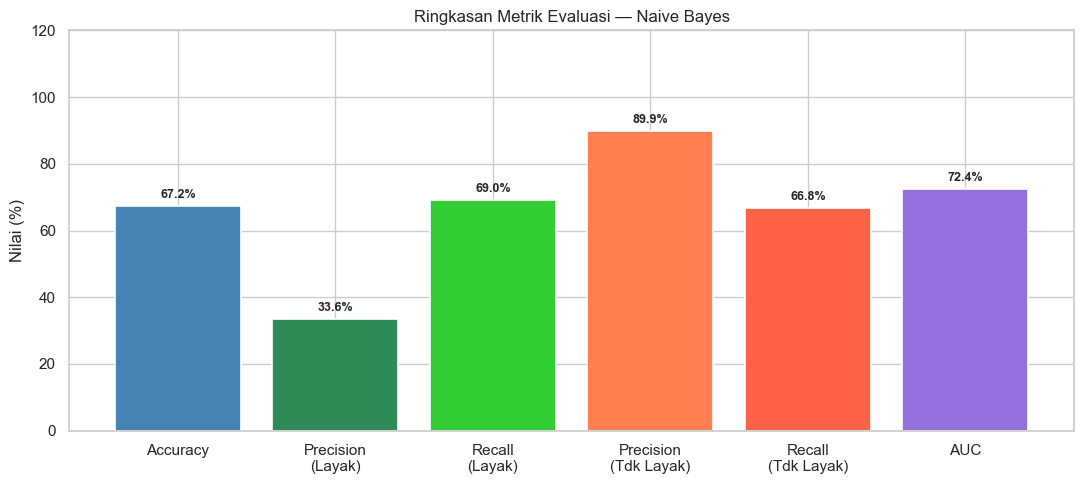

In [17]:
metrics = {
    'Accuracy': accuracy * 100,
    'Precision\n(Layak)': precision_ya * 100,
    'Recall\n(Layak)': recall_ya * 100,
    'Precision\n(Tdk Layak)': precision_tidak * 100,
    'Recall\n(Tdk Layak)': recall_tidak * 100,
    'AUC': auc_score * 100
}

colors = ['steelblue','seagreen','limegreen','coral','tomato','mediumpurple']
plt.figure(figsize=(11, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white', linewidth=1.2)
plt.ylim(0, 120)
plt.ylabel('Nilai (%)')
plt.title('Ringkasan Metrik Evaluasi — Naive Bayes')
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()